# Loading libraries and files

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import csv

# must edit filename to deserved one
#file = "../metrics/tests_MNIST/metrics_MNIST_at_[2024-06-25_14-51-36].csv"
file = "../metrics/tests_CIFAR100/metrics_CIFAR100_at_[2024-06-25_17-19-28].csv"

# must edit dataset name to deserved one
datasets = ["MNIST", "CIFAR100"]
dataset = file.split("_")[2]
print(dataset)

# setting some useful variables
NAME_MODIFIER = ""
is_old_names = False



CIFAR100


In [2]:
# making some useful functions

def plot_df_images(df, old_names=False):
    if not df.empty:
        # automatic path finding
        def get_image_path(row):
            method = row['method']
            initializer = row['initializer']
            img_idx = row['img_idx']
            exp = row['exp']

            # fixing old names so they can be found
            if old_names:
                #initializer = initializer.replace({'FB-NF':'fed_back_dirty', 'FB':'fed_back', 'original':'random'})
                initializer = initializer.replace('FB-NF', 'fed_back_dirty').replace('FB', 'fed_back').replace('original', 'random')
                # must change to deserved path, not 100% automatic yet
                return f'../results_v5.7/iDLG_{dataset}/exp_{exp}_{method}_on_[{img_idx}]_{initializer}.png'
            
            return f"../results/DLG-FB_{dataset}/exp_{exp}_{method}_on_img[{img_idx}]_{initializer}.png"

        # add image paths to dataframe
        df['image_path'] = df.apply(get_image_path, axis=1)
        # print(df['image_path'])

        # Check if exists
        df = df[df['image_path'].apply(os.path.exists)]

        # unpacking image paths
        img_file_paths = df['image_path'].tolist()

        # taking subplot information
        num_images = len(img_file_paths)
        # print(num_images)
        num_cols = 4  # columns arbitrarily choosen
        num_rows = (num_images // num_cols) + (1 if num_images % num_cols != 0 else 0)
        #num_rows = 3 # something is broken...

        # create subplots
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 3))

        # Flatten matrix for simple iteration
        axes = axes.flatten()

        # filter out empty subplots
        for ax in axes[num_images:]:
            fig.delaxes(ax)

        # plot images
        for ax, imageName in zip(axes, img_file_paths):
            img = plt.imread(imageName)
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(os.path.basename(imageName), fontsize=8)

        # adjust layout
        plt.tight_layout()
        plt.show()
    else:
        print("No images found")



# Checking if dataset is correctly loaded

In [3]:

# must edit filename to deserved one
df = pd.read_csv(file)

# testing other possibilities...
#df = df[df["exp"] < 500]

TOTAL_EXP = len(df["exp"].unique())

df

,img_idx,method,initializer,exp,iters,gt_label,dummy_label,pred_label,converged,loss,mse
0,46568,DLG,random,0,21,51,1,34,False,9.204797e+02,4.642777e+09
1,46568,DLG,FB-NF,0,21,51,51,34,False,2.358752e+02,1.160693e+09
2,46568,iDLG,random,0,21,51,51,38,False,4.985190e+02,1.157500e+08
3,46568,iDLG,FB-NF,0,21,51,51,38,False,4.661412e+02,4.534413e+09
4,33856,DLG,random,1,21,48,72,11,False,1.215409e+03,1.877281e+09
...,...,...,...,...,...,...,...,...,...,...,...
88,41431,DLG,random,19,199,21,21,10,False,3.430595e-06,2.447822e-06
89,41431,DLG,FB-NF,19,21,21,59,10,False,1.035414e+03,2.611561e+09
90,41431,iDLG,random,19,131,21,21,10,True,9.426637e-07,1.108455e-05
91,41431,iDLG,FB-NF,19,21,21,21,56,False,6.426760e+02,1.657495e+26


In [4]:
print(df.dtypes)

img_idx          int64
method          object
initializer     object
exp              int64
iters            int64
gt_label         int64
dummy_label      int64
pred_label       int64
converged         bool
loss           float64
mse            float64
dtype: object


In [5]:
# Breaks plot_df_images by now
# Correcting the old names
if is_old_names:
    df['initializer'] = df['initializer'].replace({'fed_back_dirty': 'FB-NF', 'fed_back': 'FB', 'random': 'original'})
#else:
    #df['initializer'] = df['initializer'].replace({'random': 'original'})

df

,img_idx,method,initializer,exp,iters,gt_label,dummy_label,pred_label,converged,loss,mse
0,46568,DLG,random,0,21,51,1,34,False,9.204797e+02,4.642777e+09
1,46568,DLG,FB-NF,0,21,51,51,34,False,2.358752e+02,1.160693e+09
2,46568,iDLG,random,0,21,51,51,38,False,4.985190e+02,1.157500e+08
3,46568,iDLG,FB-NF,0,21,51,51,38,False,4.661412e+02,4.534413e+09
4,33856,DLG,random,1,21,48,72,11,False,1.215409e+03,1.877281e+09
...,...,...,...,...,...,...,...,...,...,...,...
88,41431,DLG,random,19,199,21,21,10,False,3.430595e-06,2.447822e-06
89,41431,DLG,FB-NF,19,21,21,59,10,False,1.035414e+03,2.611561e+09
90,41431,iDLG,random,19,131,21,21,10,True,9.426637e-07,1.108455e-05
91,41431,iDLG,FB-NF,19,21,21,21,56,False,6.426760e+02,1.657495e+26


# Correct missing/inaccurate data

In [6]:

# simplfying the method_initializer column
df['method_initializer'] = df['method'] + '_' + df['initializer']

# Cumulated convergencies
df['convergencies'] = df.groupby('method_initializer')['converged'].cumsum()

# if not converged, it means that it took 100 iterations
df.loc[df['converged'] == False, 'iters'] = 200

# Check if worked
df.head(20)


,img_idx,method,initializer,exp,iters,gt_label,dummy_label,pred_label,converged,loss,mse,method_initializer,convergencies
0,46568,DLG,random,0,200,51,1,34,False,9.204797e+02,4.642777e+09,DLG_random,0
1,46568,DLG,FB-NF,0,200,51,51,34,False,2.358752e+02,1.160693e+09,DLG_FB-NF,0
2,46568,iDLG,random,0,200,51,51,38,False,4.985190e+02,1.157500e+08,iDLG_random,0
3,46568,iDLG,FB-NF,0,200,51,51,38,False,4.661412e+02,4.534413e+09,iDLG_FB-NF,0
4,33856,DLG,random,1,200,48,72,11,False,1.215409e+03,1.877281e+09,DLG_random,0
5,33856,DLG,FB-NF,1,200,48,48,11,False,3.225730e+02,2.611563e+09,DLG_FB-NF,0
6,33856,iDLG,random,1,200,48,48,11,False,6.717888e+00,3.596555e+01,iDLG_random,0
7,33856,iDLG,FB-NF,1,200,48,48,11,False,5.472795e+02,6.510931e+07,iDLG_FB-NF,0
8,33596,DLG,random,2,200,65,93,42,False,9.170057e+02,3.919729e+09,DLG_random,0
9,33596,DLG,FB-NF,2,200,65,65,66,False,3.615589e+02,2.611563e+09,DLG_FB-NF,0


## Dealing with false negative convergences

In [7]:
# testing values that corresponds to true convergence (it was choosen by visual analisys)
# for MNIST, loss <= 0.1 and mse <= 0.001
MIN_LOSS = 0.1; MIN_MSE = 0.001 # MNIST


df_false_negative = df.loc[(df['converged'] == False) & ((df['loss'] <= MIN_LOSS) & (df['mse'] <= MIN_MSE))].sort_values(by="mse", ascending=False)
df_false_negative
#len(df_false_negative)

,img_idx,method,initializer,exp,iters,gt_label,dummy_label,pred_label,converged,loss,mse,method_initializer,convergencies
24,20013,DLG,random,6,200,55,55,43,False,0.000007,0.000221,DLG_random,0
68,46174,DLG,random,15,200,24,24,11,False,0.000004,0.000199,DLG_random,1
83,31229,DLG,random,18,200,19,19,4,False,0.000003,0.000197,DLG_random,1
26,20013,iDLG,random,6,200,55,55,43,False,0.000005,0.000188,iDLG_random,2
18,43338,iDLG,random,4,200,48,48,94,False,0.000006,0.000188,iDLG_random,1
16,43338,DLG,random,4,200,48,48,94,False,0.000006,0.000119,DLG_random,0
85,31229,iDLG,random,18,200,19,19,4,False,0.000001,0.000080,iDLG_random,5
60,38824,iDLG,random,13,200,45,45,6,False,0.000004,0.000078,iDLG_random,4
72,46174,iDLG,FB,15,200,24,24,11,False,0.000001,0.000059,iDLG_FB,4
50,2593,iDLG,random,11,200,18,18,65,False,0.000002,0.000051,iDLG_random,4


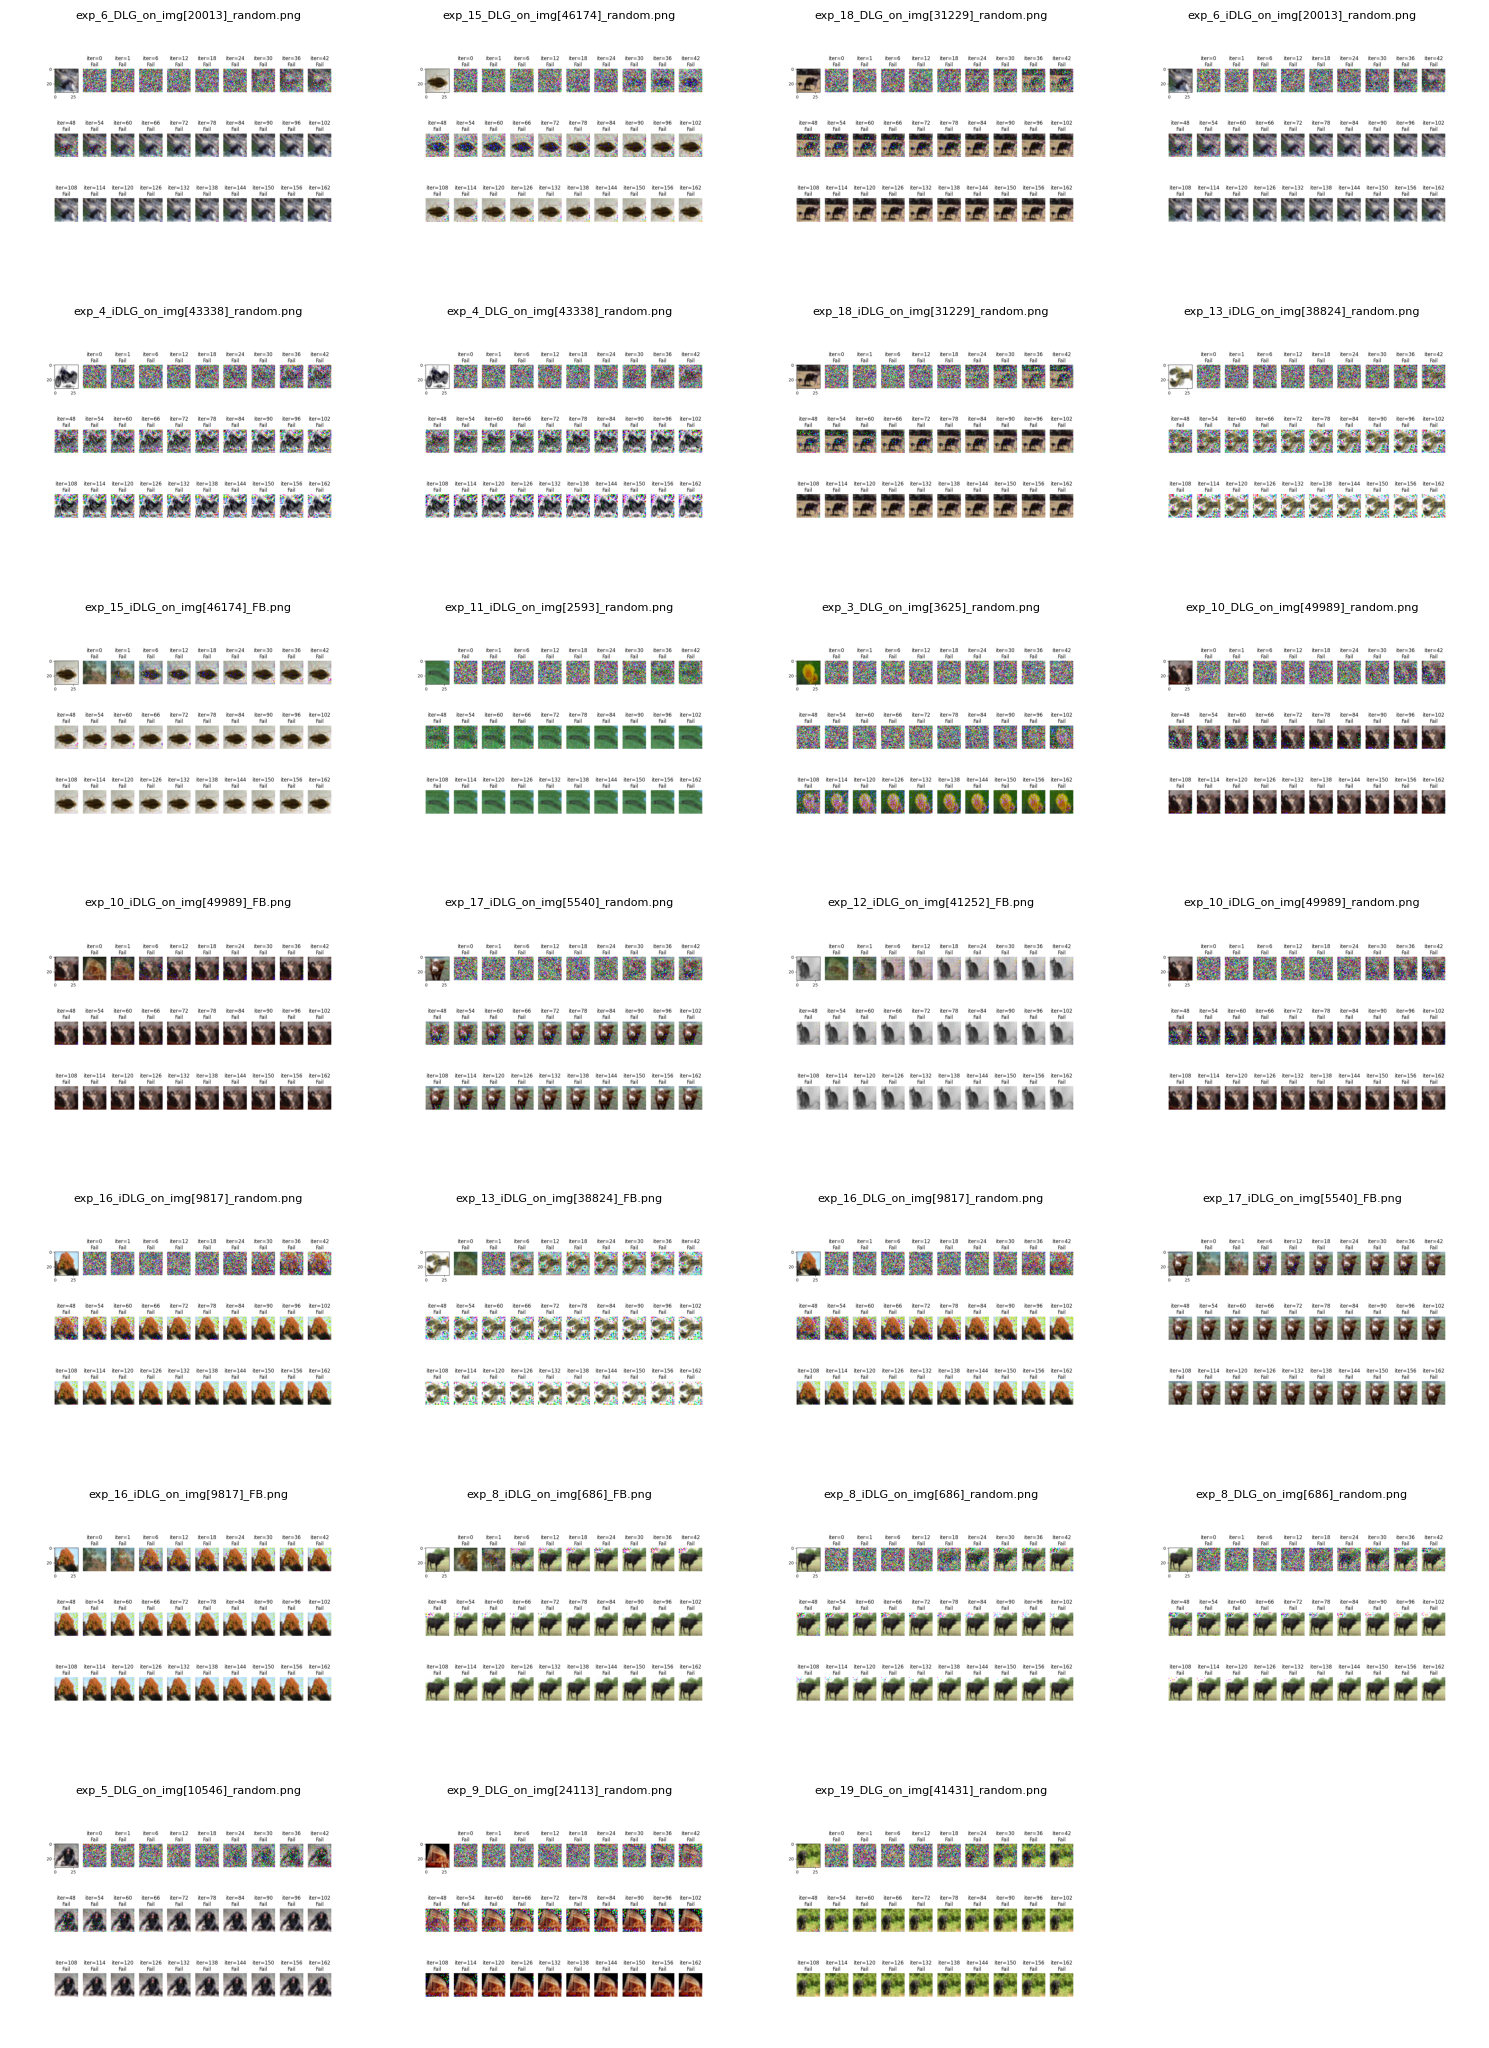

In [8]:

plot_df_images(df_false_negative, is_old_names)


In [9]:
# after visual analisys and experimentation, we may fix false negatives (if needed)
df.loc[(df['converged'] == False) & ((df['loss'] <= MIN_LOSS) & (df['mse'] <= MIN_MSE)), 'converged'] = True

### Investigating fails

In [10]:
# old
# df_fails = df.loc[(df['converged'] == False) & (df['loss'] <= 1) ].sort_values(by="loss", ascending=False)
df_fails = df.loc[(df['converged'] == False)].sort_values(by="loss", ascending=False)

df_fails

,img_idx,method,initializer,exp,iters,gt_label,dummy_label,pred_label,converged,loss,mse,method_initializer,convergencies
44,49989,DLG,FB-NF,10,200,64,53,99,False,1778.740112,2.611562e+09,DLG_FB-NF,0
29,36561,DLG,FB-NF,7,200,88,60,57,False,1289.284302,2.611563e+09,DLG_FB-NF,0
4,33856,DLG,random,1,200,48,72,11,False,1215.408569,1.877281e+09,DLG_random,0
89,41431,DLG,FB-NF,19,200,21,59,10,False,1035.413574,2.611561e+09,DLG_FB-NF,0
58,38824,DLG,random,13,200,45,7,6,False,1030.398560,5.060429e+10,DLG_random,1
0,46568,DLG,random,0,200,51,1,34,False,920.479736,4.642777e+09,DLG_random,0
8,33596,DLG,random,2,200,65,93,42,False,917.005676,3.919729e+09,DLG_random,0
39,24113,DLG,FB-NF,9,200,12,84,46,False,903.534790,2.611562e+09,DLG_FB-NF,0
49,2593,DLG,FB-NF,11,200,18,78,44,False,882.525513,2.611562e+09,DLG_FB-NF,0
34,686,DLG,FB-NF,8,200,19,40,66,False,871.604248,2.611562e+09,DLG_FB-NF,0


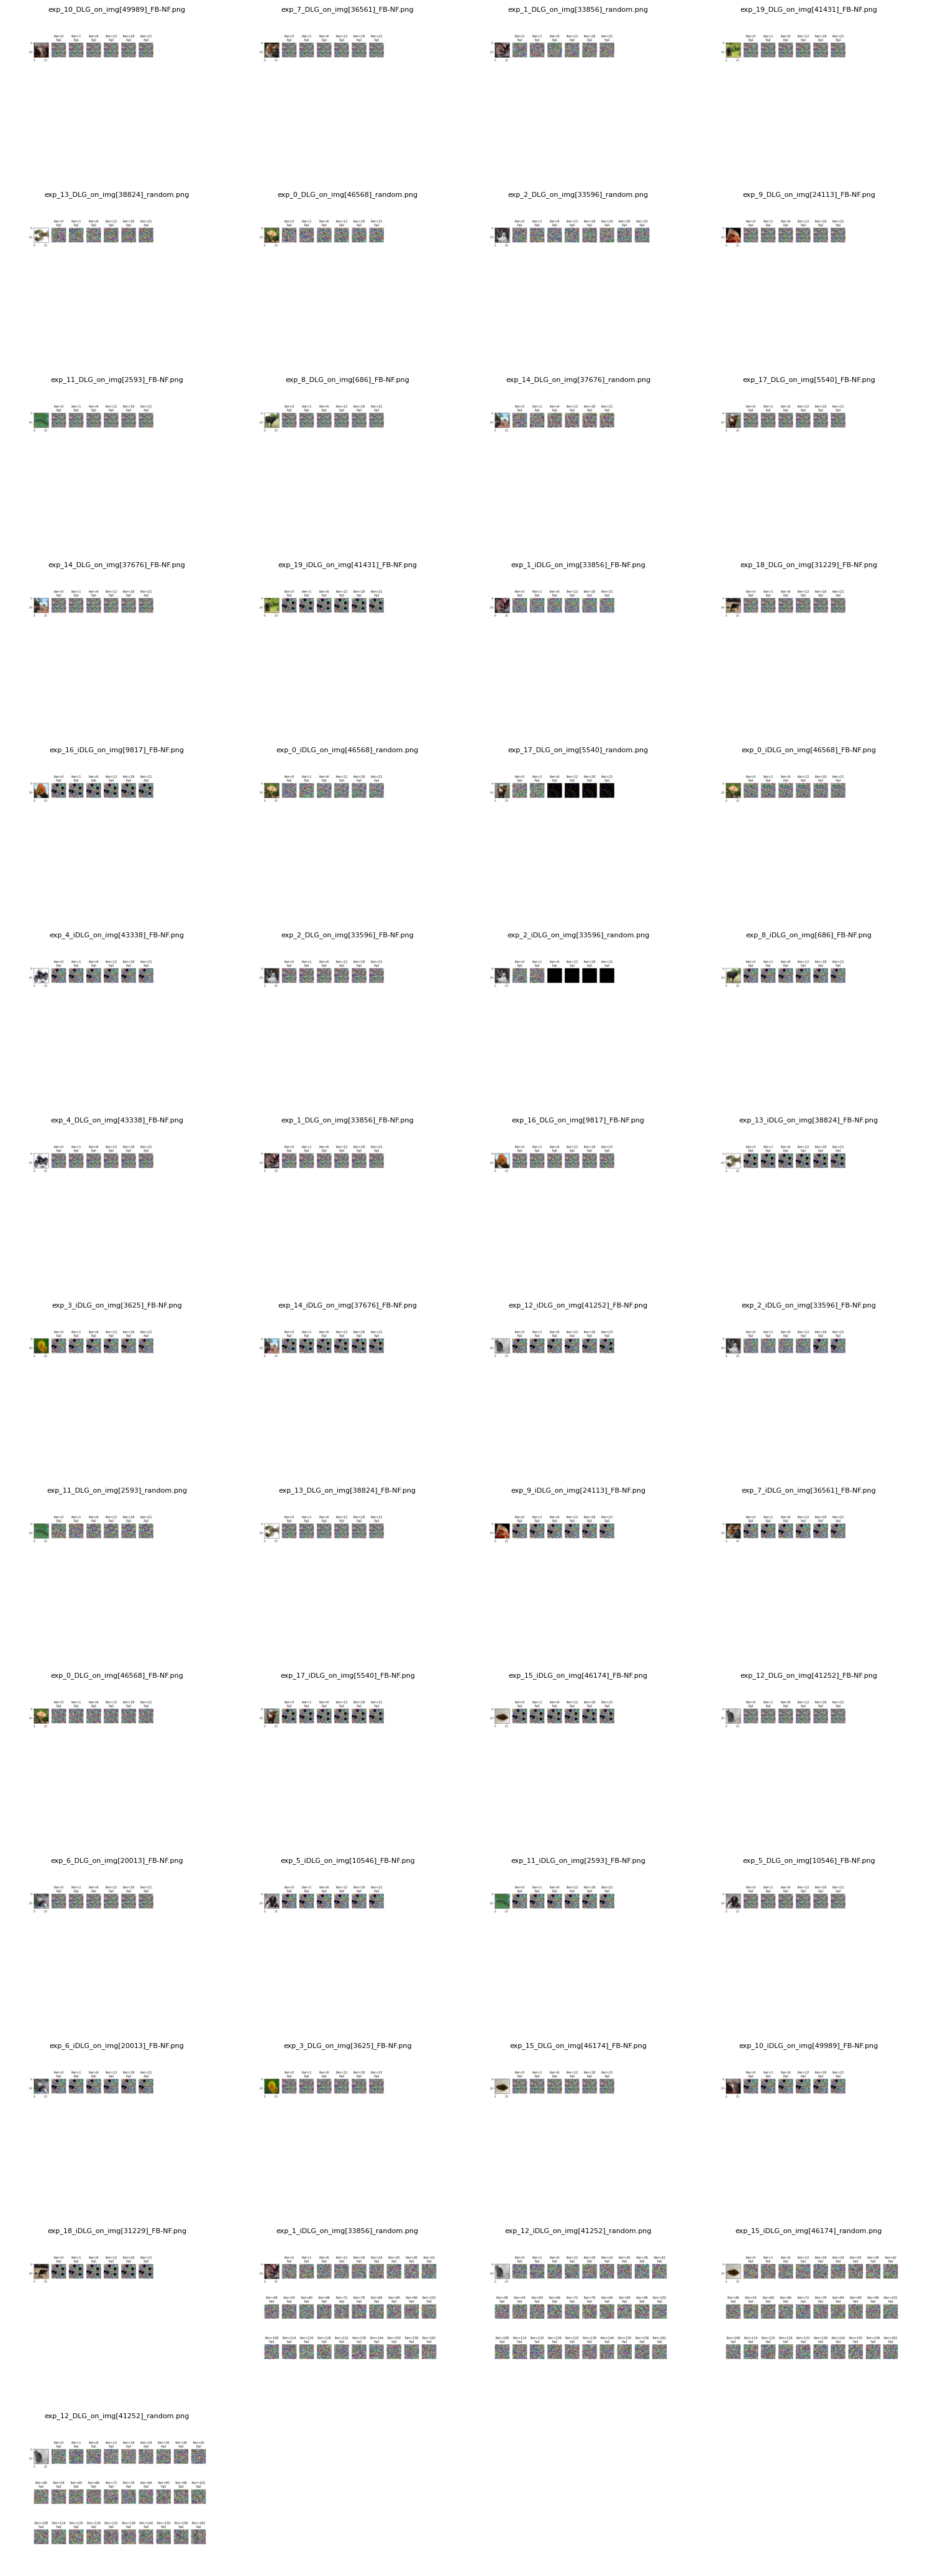

In [11]:
plot_df_images(df_fails, is_old_names)

# Understanding convergences

## false (or very noisy) positives

In [12]:
# Filtering just converged occurencies
#df_converged_sample = df[df['converged'] == True]

# Filtering just the worst converged occurencies
df_converged_sample = df[(df['converged'] == True) & (df['mse'] >= 0.0001)]

df_converged_sample


,img_idx,method,initializer,exp,iters,gt_label,dummy_label,pred_label,converged,loss,mse,method_initializer,convergencies
16,43338,DLG,random,4,200,48,48,94,True,0.000006,0.000119,DLG_random,0
18,43338,iDLG,random,4,200,48,48,94,True,0.000006,0.000188,iDLG_random,1
24,20013,DLG,random,6,200,55,55,43,True,0.000007,0.000221,DLG_random,0
26,20013,iDLG,random,6,200,55,55,43,True,0.000005,0.000188,iDLG_random,2
68,46174,DLG,random,15,200,24,24,11,True,0.000004,0.000199,DLG_random,1
83,31229,DLG,random,18,200,19,19,4,True,0.000003,0.000197,DLG_random,1


In [13]:

df_converged_sample = df_converged_sample.sort_values(by="mse", ascending=False)
#df_converged_sample = df_converged_sample.sort_values(by="loss", ascending=False)
df_converged_sample

#df.loc[(df['converged'] == True) & ((df['loss'] <= MIN_LOSS) & (df['mse'] <= MIN_MSE))].sort_values(by="mse", ascending=True)

,img_idx,method,initializer,exp,iters,gt_label,dummy_label,pred_label,converged,loss,mse,method_initializer,convergencies
24,20013,DLG,random,6,200,55,55,43,True,0.000007,0.000221,DLG_random,0
68,46174,DLG,random,15,200,24,24,11,True,0.000004,0.000199,DLG_random,1
83,31229,DLG,random,18,200,19,19,4,True,0.000003,0.000197,DLG_random,1
26,20013,iDLG,random,6,200,55,55,43,True,0.000005,0.000188,iDLG_random,2
18,43338,iDLG,random,4,200,48,48,94,True,0.000006,0.000188,iDLG_random,1
16,43338,DLG,random,4,200,48,48,94,True,0.000006,0.000119,DLG_random,0


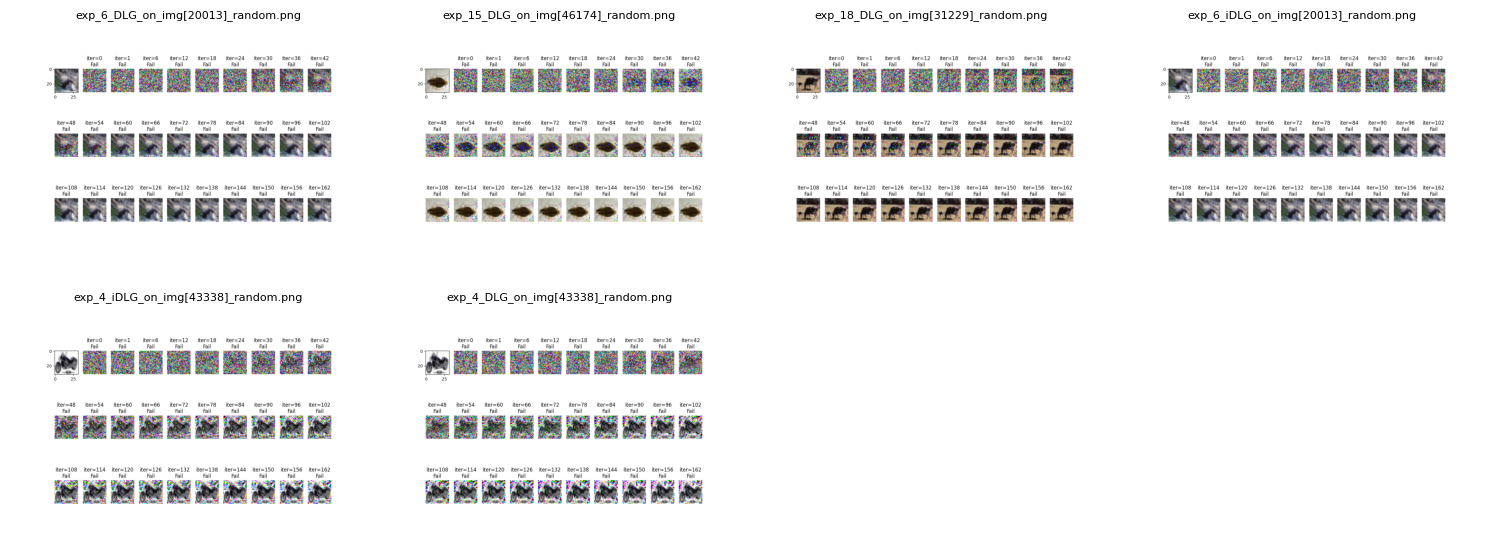

In [14]:

plot_df_images(df_converged_sample)


## Feedback with undesired noisy convergences

In [15]:

df_fb_problems = df[(df['converged'] == True) & (df['initializer'] == "FB") & (df['mse'] >= 0.00005)].sort_values(by="mse", ascending=False)
len(df_fb_problems)
df_fb_problems


,img_idx,method,initializer,exp,iters,gt_label,dummy_label,pred_label,converged,loss,mse,method_initializer,convergencies
72,46174,iDLG,FB,15,200,24,24,11,True,0.000001,0.000059,iDLG_FB,4


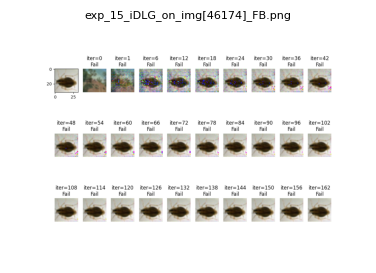

In [16]:

plot_df_images(df_fb_problems)


#### in DLG

In [17]:


df_fb_problems_dlg = df_fb_problems[(df_fb_problems['method'] == "DLG")].sort_values(by="exp", ascending=True)
df_fb_problems_dlg


,img_idx,method,initializer,exp,iters,gt_label,dummy_label,pred_label,converged,loss,mse,method_initializer,convergencies,image_path


In [18]:

plot_df_images(df_fb_problems_dlg)


No images found


#### in iDLG

In [19]:

df_fb_problems_idlg = df_fb_problems[(df_fb_problems['method'] == "iDLG")].sort_values(by="exp", ascending=True)
df_fb_problems_idlg


,img_idx,method,initializer,exp,iters,gt_label,dummy_label,pred_label,converged,loss,mse,method_initializer,convergencies,image_path
72,46174,iDLG,FB,15,200,24,24,11,True,0.000001,0.000059,iDLG_FB,4,../results/DLG-FB_CIFAR100/exp_15_iDLG_on_img[...


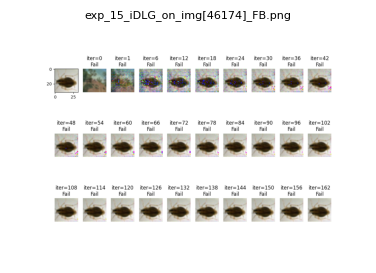

In [20]:

plot_df_images(df_fb_problems_idlg)


## visualizing fed_back_dirty failures

In [21]:

df_fbnf  = df[(df['initializer'] == "FB-NF")].sort_values(by="exp", ascending=True)

df_fbnf 


,img_idx,method,initializer,exp,iters,gt_label,dummy_label,pred_label,converged,loss,mse,method_initializer,convergencies
1,46568,DLG,FB-NF,0,200,51,51,34,False,235.875183,1.160693e+09,DLG_FB-NF,0
3,46568,iDLG,FB-NF,0,200,51,51,38,False,466.141205,4.534413e+09,iDLG_FB-NF,0
5,33856,DLG,FB-NF,1,200,48,48,11,False,322.572998,2.611563e+09,DLG_FB-NF,0
7,33856,iDLG,FB-NF,1,200,48,48,11,False,547.279541,6.510931e+07,iDLG_FB-NF,0
9,33596,DLG,FB-NF,2,200,65,65,66,False,361.558868,2.611563e+09,DLG_FB-NF,0
11,33596,iDLG,FB-NF,2,200,65,65,42,False,264.550079,6.629980e+26,iDLG_FB-NF,0
13,3625,DLG,FB-NF,3,200,62,62,26,False,166.647385,2.611562e+09,DLG_FB-NF,0
15,3625,iDLG,FB-NF,3,200,62,62,26,False,310.411957,1.657495e+26,iDLG_FB-NF,0
17,43338,DLG,FB-NF,4,200,48,48,10,False,335.424683,2.611561e+09,DLG_FB-NF,0
19,43338,iDLG,FB-NF,4,200,48,48,62,False,457.551758,1.657495e+26,iDLG_FB-NF,0


In [22]:

#plot_df_images(df_fbnf.iloc[500:550])
#plot_df_images(df_fbnf)


# Ploting metrics

In [23]:
# Seting path to save the images
graphics_path = "../graphics"
if not os.path.exists(graphics_path):
    os.makedirs(graphics_path)


## Cumulated convergencies

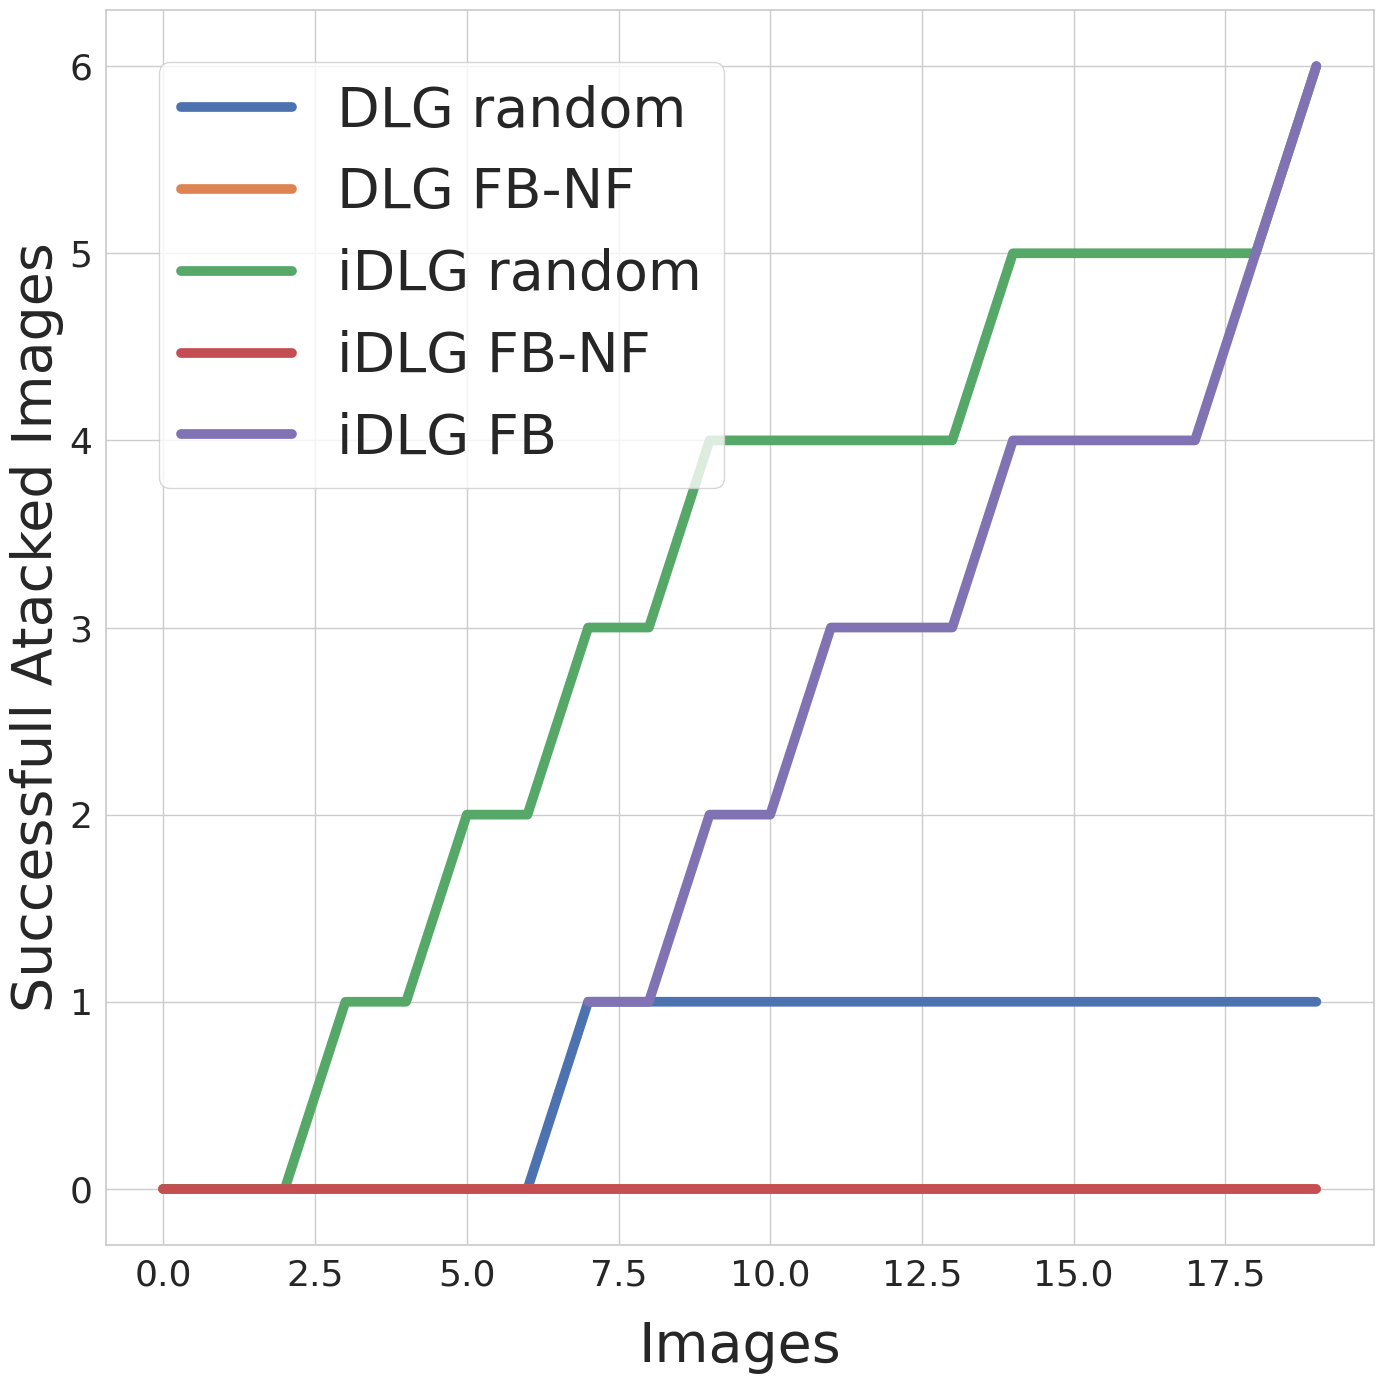

In [24]:

# Set graph theme
sns.set_theme(style="whitegrid")

# Choose figure size and proportions
#plt.figure(figsize=(14, 8))
plt.figure(figsize=(14, 14)) # used for article

# the tmp_df is just for visual purposes
tmp_df = df
tmp_df['method_initializer'] = tmp_df['method_initializer'].str.replace('_', ' ', 1)

# plot the cumulated convergencies
sns.lineplot(data=tmp_df.sort_values(by=["method", "initializer"], ascending=[True, False]), x='exp', y='convergencies', hue='method_initializer', linewidth=7.0)

# Set graph labels
#plt.title(f"Cumulated convergencies for each method-initializer\nDataset: {DATASET}", fontsize=22)

#plt.xlabel("Experiment", fontsize=20)
#plt.xlabel(f"{DATASET} Images", fontsize=34, labelpad=20) # comented for article usage
plt.xlabel(f"Images", fontsize=40, labelpad=20)

#plt.ylabel("Cumulated convergencies", fontsize=20)
plt.ylabel("Successfull Atacked Images", fontsize=40)

plt.xticks(fontsize=26)
plt.yticks(fontsize=26)

#plt.legend(title='method_initializer', bbox_to_anchor=(0.02, 0.98), loc='upper left', fontsize=18, title_fontsize=20, frameon=True)
plt.legend(bbox_to_anchor=(0.02, 0.98), loc='upper left', fontsize=40, frameon=True)


# Adjust the aspect ratio
#plt.gca().set_aspect(aspect='equal')

# Exibir o gráfico
plt.tight_layout()

#plt.savefig(f"./graphics/{DATASET}_{TOTAL_EXP}_cumulated_convergencies{NAME_MODIFIER}.png")
# saving with high resolution
plt.savefig(f"{graphics_path}/{dataset}_{TOTAL_EXP}_cumulated_convergencies{NAME_MODIFIER}.pdf", dpi=300)

plt.show()


In [25]:
# Query the maximum convergences for each method_initializer
max_convergencies = tmp_df.groupby('method_initializer')['convergencies'].max().reset_index()

max_convergencies

,method_initializer,convergencies
0,DLG FB-NF,0
1,DLG random,1
2,iDLG FB,6
3,iDLG FB-NF,0
4,iDLG random,6


In [26]:
#plot_df_images(tmp_df.loc[tmp_df["method_initializer"] == "DLG FB-NF"])

## mean iterations to converge 

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


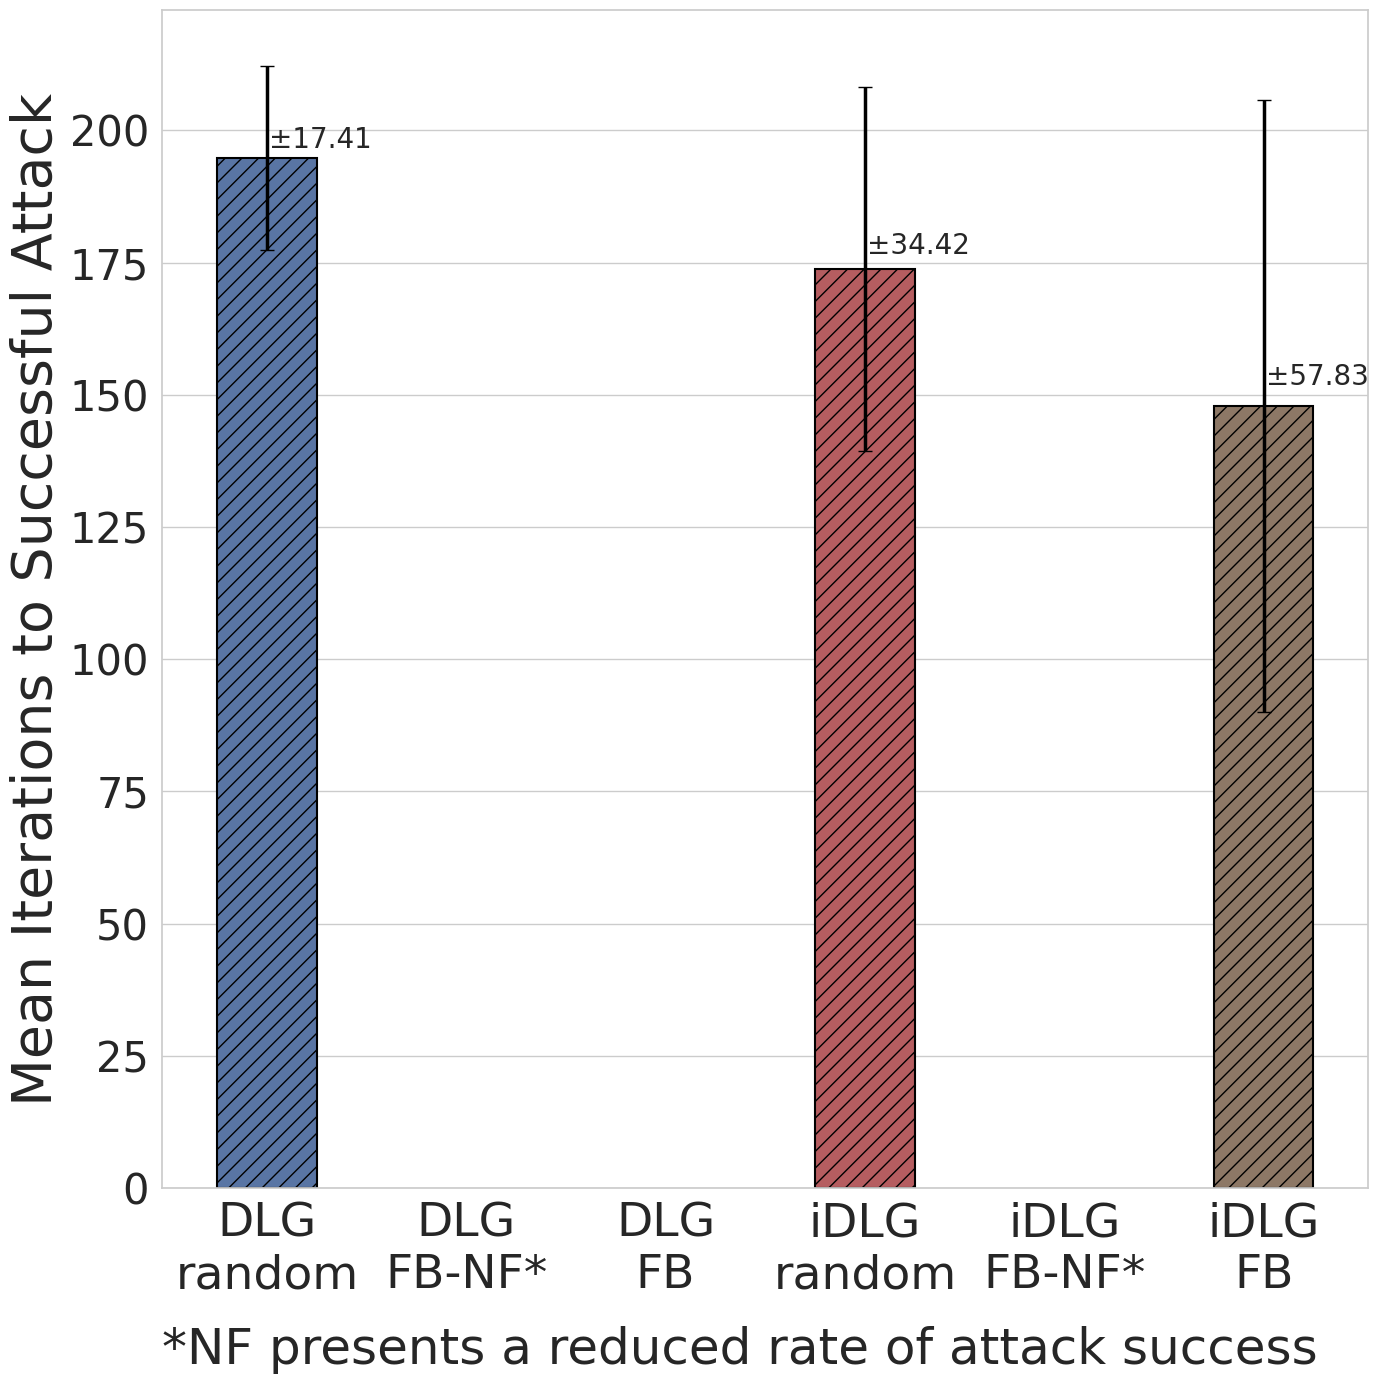

In [27]:

# Filtering just converged occurrences
df_converged = df[df['converged'] == True].sort_values(by=["method", "initializer"], ascending=[True, False])

# the tmp_df is just for visual purposes
tmp_df = df_converged.copy()
tmp_df['method_initializer'] = tmp_df['method_initializer'].str.replace(' ', '\n', 1)

# adding asterisk to NF because it has a very small sample of converged images
tmp_df['method_initializer'] = tmp_df['method_initializer'].str.replace('NF', 'NF*', 1)
# I may chage the name "random" to "original" for better understanding here
#tmp_df['method_initializer'] = tmp_df['method_initializer'].str.replace('random', 'original', 1)

# Grouping by method_initializer and calculating the mean of iters
grouped_iters = tmp_df.groupby('method_initializer')['iters']

# rearranging name order so they fit the same colors as before
mean_iters = grouped_iters.mean().reindex(['DLG\nrandom', 'DLG\nFB-NF*', 'DLG\nFB', 'iDLG\nrandom', 'iDLG\nFB-NF*', 'iDLG\nFB']).reset_index()
# "original" is the same as "random"
#mean_iters = grouped_iters.mean().reindex(['DLG\noriginal', 'DLG\nFB-NF*', 'DLG\nFB', 'iDLG\noriginal', 'iDLG\nFB-NF*', 'iDLG\nFB']).reset_index()

# Sample standard deviation, may change ddof to 1 if needed
std_iters = grouped_iters.std(ddof=0).reindex(['DLG\nrandom', 'DLG\nFB-NF*', 'DLG\nFB', 'iDLG\nrandom', 'iDLG\nFB-NF*', 'iDLG\nFB']).reset_index()

# Setting theme
sns.set_theme(style="whitegrid")

# Customizing colors
palette = sns.color_palette("deep", len(mean_iters))

# Choose figure size and proportions
plt.figure(figsize=(14, 14))

# Plotting barplot
sns.barplot(data=mean_iters, x='method_initializer', y='iters', hue='method_initializer', palette=palette, width=0.5, hatch='//', edgecolor='black', linewidth=1.5, dodge=False, legend=False)

# Adding error bars representing standard deviation
plt.errorbar(range(len(mean_iters)), mean_iters['iters'], yerr=std_iters['iters'], fmt='none', color='black', capsize=5, linewidth=2.5)

# Adding text with standard deviation values
for i, std in enumerate(std_iters['iters']):
    plt.text(i + 0.27, mean_iters['iters'][i] + 0.05 * std, f"±{std:.2f}", ha='center', va='bottom', fontsize=20)

# Labeling graphic
# plt.xlabel(f'Dataset: {DATASET}\nExperiments:{TOTAL_EXP}', fontsize=40, labelpad=20) # comented for article usage
plt.xlabel(f'*NF presents a reduced rate of attack success', fontsize=36, loc="left", labelpad=20)
plt.ylabel('Mean Iterations to Successful Attack', fontsize=40)

# Rotating x labels so they are readable
plt.xticks(fontsize=34)
plt.yticks(fontsize=30)

# Adjust y-axis to start from zero
plt.ylim(bottom=0)

# Plotting
plt.tight_layout()

# Saving with high resolution
plt.savefig(f"{graphics_path}/{dataset}_{TOTAL_EXP}_mean_iter{NAME_MODIFIER}.pdf", dpi=300)

plt.show()


In [28]:
mean_iters


,method_initializer,iters
0,DLG\nrandom,194.750000
1,DLG\nFB-NF*,NaN
2,DLG\nFB,NaN
3,iDLG\nrandom,173.800000
4,iDLG\nFB-NF*,NaN
5,iDLG\nFB,147.923077
